## Q6 — What If? Scenarios

Two research questions:

**Q6a** — Does it matter *where* we deploy interceptors? Comparing global optimal deployment vs Europe-only vs high-income countries only.

**Q6b** — Can cleanup growth outpace plastic input? Growth projections at different CAGR rates, with and without plastic production growth.

---


In [1]:
import sys
sys.path.append('../Src')

import pandas as pd
import yaml
from q6_what_if_functions import (
    merge_income_group,
    get_continent_breakdown,
    get_income_breakdown,
    build_strategy_comparison,
    plot_strategy_comparison,
    years_to_parity,
    years_to_parity_moving_target,
    interceptors_needed_per_year,
    plot_growth_projection,
    ANNUAL_INPUT_T, GUATEMALA_T_PER_YEAR,
    BEST_CLEANUP_T, HISTORICAL_CAGR, PLASTIC_GROWTH,
)

with open('../config.yaml') as f:
    config = yaml.safe_load(f)

print('✅ imports done')

✅ imports done


In [2]:
rivers  = pd.read_parquet(config['output_data_modular']['file1'])
pvp     = pd.read_parquet(config['output_data_modular']['file7'])

# Merge income group onto rivers
rivers  = merge_income_group(rivers, pvp)

print(f'Rivers loaded   : {len(rivers):,} rows')
print(f'Income groups   : {rivers["income_group"].nunique()}')
print(f'Continents      : {rivers["continent"].nunique()}')

⚠ 1899 river mouths could not be matched to an income group.
Rivers loaded   : 31,819 rows
Income groups   : 5
Continents      : 6


---
## Q6a — Deployment Strategy Comparison

### H1 — Europe and high-income countries contribute a negligible share of global river plastic emissions

In [3]:
continent_df = get_continent_breakdown(rivers)
print(continent_df.to_string(index=False))

    continent      emission  pct_of_global
         Asia 825475.700394          82.06
       Africa  76238.930884           7.58
South America  53763.256714           5.34
North America  40981.461427           4.07
       Europe   5552.884063           0.55
      Oceania   3971.913170           0.39


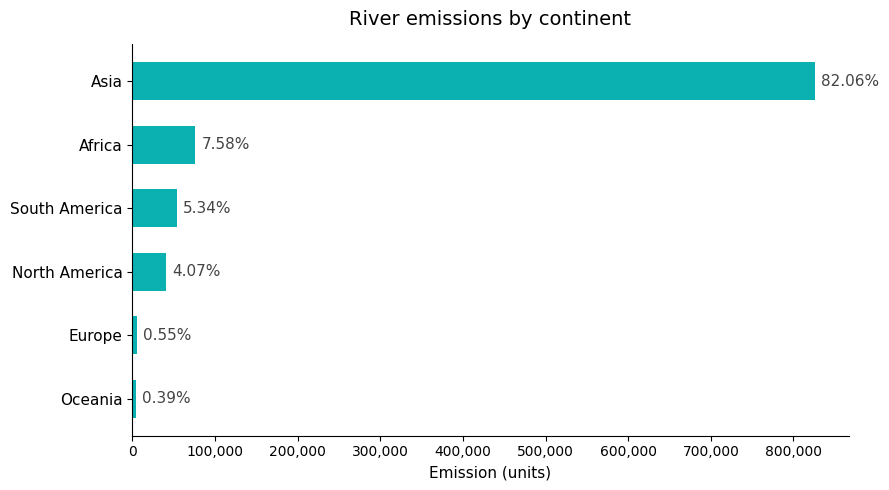

In [13]:
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Asia":          (825475.70, 82.06),
    "Africa":         (76238.93,  7.58),
    "South America":  (53763.26,  5.34),
    "North America":  (40981.46,  4.07),
    "Europe":          (5552.88,  0.55),
    "Oceania":         (3971.91,  0.39),
}

continents = list(data.keys())
emissions  = [v[0] for v in data.values()]
pcts       = [v[1] for v in data.values()]

colors = ["#0BB1B1"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(continents, emissions, color=colors, height=0.6)

for bar, pct in zip(bars, pcts):
    ax.text(
        bar.get_width() + 8000,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.2f}%",
        va="center", ha="left", fontsize=11, color="#444"
    )

ax.set_xlabel("Emission (units)", fontsize=11)
ax.set_title("River emissions by continent", fontsize=14, fontweight="normal", pad=14)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()
plt.savefig("continent_emissions.png", dpi=150, bbox_inches="tight")
plt.show()

> **H1 confirmed:** Europe contributes only **0.55%** of global river plastic input.
> Asia dominates at **82%**, driven by the Philippines, India, Malaysia and China.
> The hypothesis is confirmed — Europe's contribution is negligible at global scale.

In [4]:
### H2 — Deploying interceptors in high-income countries is significantly less effective than optimal global deployment

In [5]:
income_df = get_income_breakdown(rivers)
print(income_df.to_string(index=False))

                 income_group      emission  pct_of_global
Lower-middle-income countries 648262.781061          64.44
Upper-middle-income countries 306971.616263          30.51
        High-income countries  18806.887711           1.87
         Low-income countries  10543.485474           1.05
                      Unknown   5961.299912           0.59


> Lower and upper-middle income countries account for **95%** of global river plastic.
> High-income countries contribute just **1.87%** despite producing the most plastic per capita.
> The disconnect is waste management infrastructure — rich countries capture their waste before it reaches rivers.

### H2 continued — Strategy comparison: same interceptors, different deployment

In [6]:
df_compare = build_strategy_comparison(rivers, ns=[10, 20, 50, 100, 150, 200])
print(df_compare.to_string(index=False))

 interceptors  global_optimal_%  high_income_%  europe_%
           10             14.71           0.40      0.17
           20             18.70           0.62      0.23
           50             26.49           0.93      0.31
          100             34.54           1.15      0.37
          150             40.28           1.27      0.40
          200             44.76           1.35      0.42


In [7]:
fig = plot_strategy_comparison(df_compare)
fig.show()

> **H2 confirmed:** 101 interceptors deployed optimally offset **34.5%** of global input.
> The same 101 interceptors in high-income countries offset only **1.15%** — **30x less effective**.
> In Europe only: **0.37%** — **93x less effective**.
>
> WHERE you deploy matters as much as HOW MANY you deploy.

---
## Q6b — Growth Projection

### H3 — At historical cleanup growth rates, parity with annual plastic input is reachable before 2040

In [8]:
growth_rates = [0.20, 0.30, 0.40, 0.50]

parity_fixed = years_to_parity(growth_rates)
print('=== Fixed plastic input ===')
print(parity_fixed.to_string(index=False))

=== Fixed plastic input ===
 cagr_%  years  parity_year
     20   19.5         2044
     30   13.5         2039
     40   10.6         2036
     50    8.8         2034


In [9]:
parity_moving = years_to_parity_moving_target(growth_rates)
print(f'=== Moving target ({PLASTIC_GROWTH*100:.0f}% plastic growth/yr) ===')
print(parity_moving.to_string(index=False))

=== Moving target (4% plastic growth/yr) ===
 cagr_%  parity_year  input_at_parity
     20         2050          2668502
     30         2041          1874854
     40         2037          1602633
     50         2035          1481725


> **H3 partially confirmed:** At the historical **40% CAGR**, cleanup reaches parity around **2036-2037** — before 2040. ✅
> However, this assumes plastic input stays flat.
> With **4% annual plastic production growth**, parity shifts to **2037** — still before 2040, but only just.
> And by then plastic input will have grown to ~**1.4-1.6M t/yr** — the problem is 40-60% bigger than today.
> **H3 is confirmed but with an important caveat:** cleanup alone cannot solve this without production reduction.

In [10]:
fig2 = plot_growth_projection(growth_rates)
fig2.show()

In [11]:
intercept_df = interceptors_needed_per_year(
    target_years=[2030, 2035, 2040, 2050],
    efficiency=0.5,
)
print(intercept_df.to_string(index=False))

 target_year  years_left  total_interceptors  deployments_per_year
        2030           5                 195                    39
        2035          10                 195                    20
        2040          15                 195                    13
        2050          25                 195                     8


---
## Summary & Conclusions

### H1 — Europe and high-income countries contribute a negligible share ✅ Confirmed
| Region | % of global river plastic |
|---|---|
| Asia | 82.1% |
| Africa | 7.6% |
| South America | 5.3% |
| North America | 4.1% |
| **Europe** | **0.55%** |
| **High-income countries** | **1.87%** |

### H2 — Optimal deployment is significantly more effective ✅ Confirmed
| Strategy | 101 interceptors | % of global input | vs optimal |
|---|---|---|---|
| Global optimal | top emitting rivers | 34.5% | baseline |
| High-income only | rich world rivers | 1.15% | 30x less |
| Europe only | European rivers | 0.37% | 93x less |

### H3 — Parity reachable before 2040 ✅ Confirmed with caveat
| Cleanup CAGR | Parity (fixed input) | Parity (4% plastic growth) |
|---|---|---|
| 20% | 2044 | 2050 |
| 30% | 2039 | 2041 |
| 40% | **2036** | **2037** |
| 50% | 2034 | 2035 |

**Overall conclusion:** The data supports all three hypotheses, but H3 comes with a critical caveat —
parity is only reachable if plastic production growth slows or policy intervention reduces input.
Cleanup technology alone is not sufficient. Reducing production at source remains essential.

*Sources: Meijer et al. 2021 (rivers), PlasticsEurope 2024 (plastic growth rate)*